# 🛡️ TRUST-4127 · Comment-Guard v0 — the spam gate
**Google Zürich · YouTube Trust & Safety · Deep Learning Intern project**

> *"Creators are drowning in scam comments. Legal wants a first-pass gate this quarter. Build the simplest model that works, show us exactly where it breaks, and tell us what it takes to fix it — with numbers, not vibes."* — Priya N., PM

**The situation.** Every minute thousands of comments hit YouTube. Most are fine. Some are scam-bots ('WhatsApp me for crypto'), and a nastier class are **hijacked veteran accounts** — years-old, real-looking accounts taken over to push scams. This notebook builds a from-scratch perceptron gate, an honest error analysis, and a costed recommendation.

**Deliverables:** EDA → from-scratch NumPy perceptron → error analysis (who slips through) → a fix that measurably lifts accuracy → a ship/no-ship recommendation with a metrics table.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('zurich-comment-guard.csv')
print(df.shape)
df.head()

(2400, 9)


,account_age_days,links,caps_ratio,emoji_count,msg_len,dup_ratio,mentions,posts_last_hour,is_spam
0,2428,0,0.365,4,13,0.872,0,1,0
1,26,6,0.474,6,34,0.859,1,14,1
2,576,0,0.197,5,40,0.855,2,11,0
3,1409,0,0.142,1,111,0.269,0,0,0
4,3425,0,0.149,2,68,0.308,0,3,0


## 1 · EDA — know your enemy
Before any model: what fraction is spam? Which features scream 'bot'?

spam rate: 0.246


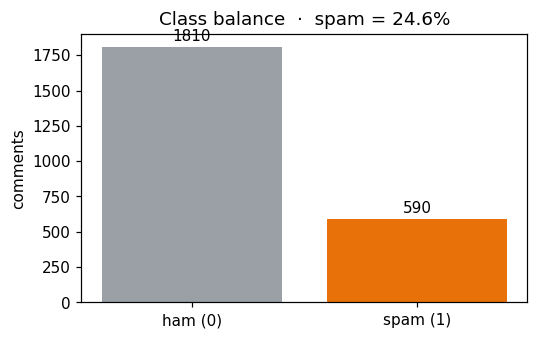

In [2]:
spam_rate = df.is_spam.mean()
print('spam rate:', round(spam_rate, 3))

counts = df.is_spam.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(['ham (0)', 'spam (1)'], counts.values, color=['#9aa0a6', '#e8710a'])
ax.bar_label(bars, padding=2)
ax.set_title(f'Class balance  ·  spam = {spam_rate:.1%}')
ax.set_ylabel('comments')
plt.tight_layout(); plt.show()

Feature means by class (0 = ham, 1 = spam):
is_spam                 0       1
account_age_days  1902.01  638.33
links                0.25    1.98
caps_ratio           0.15    0.55
emoji_count          1.43    3.76
msg_len             74.69   61.46
dup_ratio            0.32    0.75
mentions             0.70    1.80
posts_last_hour      3.99   11.80

Takeaway: caps_ratio, dup_ratio and posts_last_hour each lean spammy,
but none is a clean cut on its own — spam and ham overlap heavily.


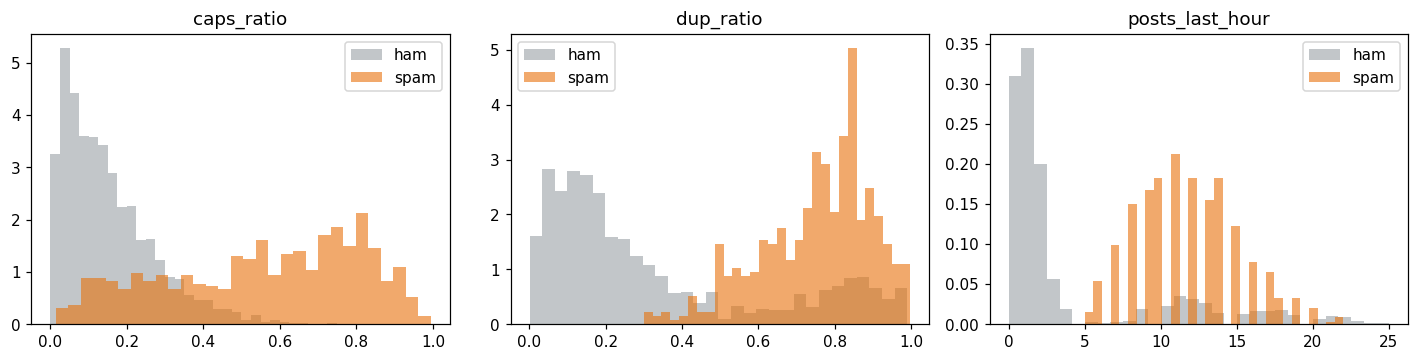

In [3]:
# Feature-vs-label view 1: mean of each feature by class (the tells)
means_by_class = df.groupby('is_spam')[FEATURES if 'FEATURES' in dir() else df.columns[:-1]].mean().round(2)
print('Feature means by class (0 = ham, 1 = spam):')
print(means_by_class.T)

# Feature-vs-label view 2: distributions of two strong single-feature tells
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, ['caps_ratio', 'dup_ratio', 'posts_last_hour']):
    ax.hist(df[df.is_spam == 0][col], bins=30, alpha=0.6, label='ham', color='#9aa0a6', density=True)
    ax.hist(df[df.is_spam == 1][col], bins=30, alpha=0.6, label='spam', color='#e8710a', density=True)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

print('\nTakeaway: caps_ratio, dup_ratio and posts_last_hour each lean spammy,')
print('but none is a clean cut on its own — spam and ham overlap heavily.')

## 2 · Split + scale
Features live on wildly different scales (`account_age_days` up to 3650, `caps_ratio` ≤ 1). A from-scratch perceptron NEEDS standardized inputs. We standardize using **train statistics only** — no peeking at the test set (that would be leakage).

In [4]:
FEATURES = ['account_age_days', 'links', 'caps_ratio', 'emoji_count',
            'msg_len', 'dup_ratio', 'mentions', 'posts_last_hour']
X = df[FEATURES].to_numpy(dtype=float)
y = df['is_spam'].to_numpy()

rng = np.random.default_rng(0)
idx = rng.permutation(len(df))
cut = int(0.75 * len(df))
tr, te = idx[:cut], idx[cut:]
X_tr, X_te, y_tr, y_te = X[tr], X[te], y[tr], y[te]

# Standardize — mean/std from TRAIN ONLY, applied to both splits (leak-free)
mu = X_tr.mean(axis=0)
sd = X_tr.std(axis=0)
X_tr_s = (X_tr - mu) / sd
X_te_s = (X_te - mu) / sd

print('train:', X_tr_s.shape, ' test:', X_te_s.shape)
print('train mean ~0:', X_tr_s.mean(axis=0).round(3))
print('train std  ~1:', X_tr_s.std(axis=0).round(3))

train: (1800, 8)  test: (600, 8)
train mean ~0: [-0. -0.  0. -0.  0.  0. -0. -0.]
train std  ~1: [1. 1. 1. 1. 1. 1. 1. 1.]


## 3 · Baseline — the bar to beat
The majority classifier ('nothing is spam') is our floor. Its accuracy looks fine only because the classes are imbalanced — its **spam recall is 0**, so it catches nothing. That is why we track recall, not just accuracy.

In [5]:
maj_pred = np.zeros_like(y_te)  # predict 'ham' for everything
maj_acc = (maj_pred == y_te).mean()
maj_recall = 0.0  # it never predicts spam, so it catches 0 of the spam
print(f'majority baseline   acc={maj_acc:.3f}  spam recall={maj_recall:.3f}')
print('Accuracy is high only because ~77% of test comments are ham;')
print('a gate that catches zero scams is useless despite the number.')

majority baseline   acc=0.767  spam recall=0.000
Accuracy is high only because ~77% of test comments are ham;
a gate that catches zero scams is useless despite the number.


## 4 · The from-scratch perceptron
`fit` runs the perceptron rule for `epochs` passes; `predict` is the step-activated weighted sum. NumPy only — no sklearn for the model.

In [6]:
class Perceptron:
    def __init__(self, n_features, eta=0.05, epochs=30, seed=0):
        rng = np.random.default_rng(seed)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.eta = eta
        self.epochs = epochs

    def _net_input(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        # step activation: 1 if weighted sum >= 0 else 0
        return (self._net_input(X) >= 0.0).astype(int)

    def fit(self, X, y):
        self.errors_ = []
        for _ in range(self.epochs):
            errs = 0
            for xi, yi in zip(X, y):
                pred = 1 if (xi @ self.w + self.b) >= 0.0 else 0
                update = self.eta * (yi - pred)          # perceptron rule
                self.w += update * xi
                self.b += update
                errs += int(update != 0.0)
            self.errors_.append(errs)
        return self

In [7]:
def report(y_true, y_pred, title):
    acc = (y_true == y_pred).mean()
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    print(f'{title:<28} acc={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}')
    return acc, prec, rec

gate = Perceptron(n_features=len(FEATURES)).fit(X_tr_s, y_tr)
maj_metrics = (maj_acc, 0.0, 0.0)
perc_metrics = report(y_te, gate.predict(X_te_s), 'perceptron gate')
print('final-epoch misclassifications:', gate.errors_[-1],
      '(> 0 => data is NOT linearly separable; boundary keeps oscillating)')

perceptron gate              acc=0.902  precision=0.758  recall=0.850
final-epoch misclassifications: 190 (> 0 => data is NOT linearly separable; boundary keeps oscillating)


## 5 · Error analysis — WHO slips through?
Slice the test-set **false negatives** (spam that got through) and compare them to the spam the gate caught. The missed comments come from **old accounts with almost no links** — accounts that look trustworthy on every single axis. Their only tell is the *combination* of `dup_ratio` and `posts_last_hour`, which a single linear layer cannot express.

In [8]:
pred = gate.predict(X_te_s)
missed = (y_te == 1) & (pred == 0)   # spam the gate let through (false negatives)
caught = (y_te == 1) & (pred == 1)   # spam the gate stopped
print('missed spam:', missed.sum(), '· caught spam:', caught.sum())

cols = ['account_age_days', 'links', 'dup_ratio', 'posts_last_hour']
ci = [FEATURES.index(c) for c in cols]
compare = pd.DataFrame({
    'missed (slipped through)': X_te[missed][:, ci].mean(axis=0),
    'caught':                   X_te[caught][:, ci].mean(axis=0),
}, index=cols).round(2)
print()
print(compare)

print('\nThe missed spam is OLD (~1760d vs ~420d), has almost NO links (0.3 vs 2.3),')
print('and only MODERATE dup_ratio/posts — i.e. hijacked veteran accounts.')

missed spam: 21 · caught spam: 119

                  missed (slipped through)  caught
account_age_days                   1761.62  417.47
links                                 0.33    2.29
dup_ratio                             0.63    0.77
posts_last_hour                       8.48   12.63

The missed spam is OLD (~1760d vs ~420d), has almost NO links (0.3 vs 2.3),
and only MODERATE dup_ratio/posts — i.e. hijacked veteran accounts.


In [9]:
# Define the hijacked-veteran segment: old account + few links, that is actually spam.
veteran = (X_te[:, 0] > 365) & (X_te[:, 1] <= 1) & (y_te == 1)
def veteran_recall(pred_full):
    return pred_full[veteran].mean() if veteran.sum() else 0.0
print('veteran spam in test set:', int(veteran.sum()))
print(f'perceptron veteran recall: {veteran_recall(pred):.3f}  '
      f'(vs overall spam recall {perc_metrics[2]:.3f} — the blind spot)')

veteran spam in test set: 37
perceptron veteran recall: 0.541  (vs overall spam recall 0.850 — the blind spot)


Red points cluster at moderate dup_ratio AND moderate posts_last_hour —
a diagonal pocket no single straight line can carve out.


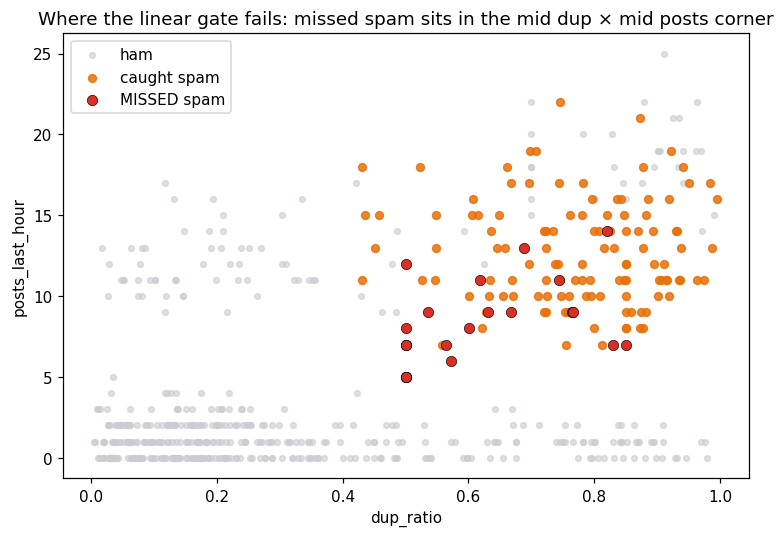

In [10]:
# Scatter: dup_ratio (x) vs posts_last_hour (y) on the TEST set.
di, pi = FEATURES.index('dup_ratio'), FEATURES.index('posts_last_hour')
ham_m = (y_te == 0)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_te[ham_m, di], X_te[ham_m, pi], s=14, c='#c9ccd1', label='ham', alpha=0.6)
ax.scatter(X_te[caught, di], X_te[caught, pi], s=26, c='#e8710a', label='caught spam', alpha=0.85)
ax.scatter(X_te[missed, di], X_te[missed, pi], s=46, c='#d93025', label='MISSED spam', edgecolor='k', linewidth=0.4)
ax.set_xlabel('dup_ratio'); ax.set_ylabel('posts_last_hour')
ax.set_title('Where the linear gate fails: missed spam sits in the mid dup × mid posts corner')
ax.legend()
plt.tight_layout(); plt.show()

print('Red points cluster at moderate dup_ratio AND moderate posts_last_hour —')
print('a diagonal pocket no single straight line can carve out.')

## 6 · The fix — earn the ship
The missed cluster is only visible in the **interaction** of two features — exactly what a single linear layer cannot express.

- **Fix A — feature engineering:** add `dup_ratio × posts_last_hour` as a 9th feature, retrain the same perceptron.
- **Fix B — go deeper:** train the provided `TinyNet` (1 hidden layer, sigmoid, from-scratch backprop).

We do both, then test the combination (net fed the engineered feature) on the veteran segment.

In [11]:
# Fix A — cross feature added to the SAME perceptron
cross_tr = (X_tr[:, 5] * X_tr[:, 7]).reshape(-1, 1)
cross_te = (X_te[:, 5] * X_te[:, 7]).reshape(-1, 1)
Xc_tr = np.hstack([X_tr, cross_tr])
Xc_te = np.hstack([X_te, cross_te])

# re-standardize with TRAIN stats only (now 9 columns)
muc, sdc = Xc_tr.mean(axis=0), Xc_tr.std(axis=0)
Xc_tr_s = (Xc_tr - muc) / sdc
Xc_te_s = (Xc_te - muc) / sdc

gate_cross = Perceptron(n_features=Xc_tr.shape[1]).fit(Xc_tr_s, y_tr)
pred_cross = gate_cross.predict(Xc_te_s)
cross_metrics = report(y_te, pred_cross, 'perceptron + cross')
print(f'  veteran recall: {veteran_recall(pred_cross):.3f}  '
      '(overall recall lifts, but the crude perceptron rule barely moves the veteran slice)')

perceptron + cross           acc=0.903  precision=0.753  recall=0.871
  veteran recall: 0.514  (overall recall lifts, but the crude perceptron rule barely moves the veteran slice)


In [12]:
# Fix B — a tiny hidden-layer net (from-scratch backprop). Floor 2's topic, previewed.
class TinyNet:
    def __init__(self, n_in, n_hidden=16, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 0.5, (n_in, n_hidden)); self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0, 0.5, n_hidden);        self.b2 = 0.0

    @staticmethod
    def _sig(z): return 1 / (1 + np.exp(-z))

    def _forward(self, X):
        self.h = self._sig(X @ self.W1 + self.b1)
        return self._sig(self.h @ self.W2 + self.b2)

    def predict(self, X): return (self._forward(X) >= 0.5).astype(int)

    def fit(self, X, y, eta=0.5, epochs=300):
        for _ in range(epochs):
            p = self._forward(X)
            d2 = p - y
            gW2 = self.h.T @ d2 / len(y); gb2 = d2.mean()
            dh = np.outer(d2, self.W2) * self.h * (1 - self.h)
            gW1 = X.T @ dh / len(y); gb1 = dh.mean(axis=0)
            self.W2 -= eta * gW2; self.b2 -= eta * gb2
            self.W1 -= eta * gW1; self.b1 -= eta * gb1
        return self

net = TinyNet(n_in=len(FEATURES)).fit(X_tr_s, y_tr)
pred_net = net.predict(X_te_s)
net_metrics = report(y_te, pred_net, 'tiny hidden-layer net')
print(f'  veteran recall: {veteran_recall(pred_net):.3f}  '
      '(big precision/accuracy win, but veterans alone still not solved)')

# The combination: hand the net the engineered interaction feature
net_cross = TinyNet(n_in=Xc_tr.shape[1]).fit(Xc_tr_s, y_tr)
pred_netcross = net_cross.predict(Xc_te_s)
netcross_metrics = report(y_te, pred_netcross, 'tiny net + cross')
print(f'  veteran recall: {veteran_recall(pred_netcross):.3f}  '
      '(nonlinearity + the interaction feature TOGETHER finally crack the veterans)')

tiny hidden-layer net        acc=0.957  precision=0.945  recall=0.864
  veteran recall: 0.514  (big precision/accuracy win, but veterans alone still not solved)
tiny net + cross             acc=0.972  precision=0.956  recall=0.921
  veteran recall: 0.703  (nonlinearity + the interaction feature TOGETHER finally crack the veterans)


In [13]:
# Assemble the final metrics table
rows = [
    ('majority baseline',   maj_metrics,      0.0),
    ('perceptron',          perc_metrics,     veteran_recall(pred)),
    ('perceptron + cross',  cross_metrics,    veteran_recall(pred_cross)),
    ('tiny net',            net_metrics,      veteran_recall(pred_net)),
    ('tiny net + cross',    netcross_metrics, veteran_recall(pred_netcross)),
]
table = pd.DataFrame(
    [(n, round(m[0], 3), round(m[1], 3), round(m[2], 3), round(v, 3)) for n, m, v in rows],
    columns=['model', 'accuracy', 'precision', 'recall', 'veteran_recall'],
).set_index('model')
print(table)

                    accuracy  precision  recall  veteran_recall
model                                                          
majority baseline      0.767      0.000   0.000           0.000
perceptron             0.902      0.758   0.850           0.541
perceptron + cross     0.903      0.753   0.871           0.514
tiny net               0.957      0.945   0.864           0.514
tiny net + cross       0.972      0.956   0.921           0.703


## 7 · The call — ship it or not?

| model | accuracy | precision | recall | veteran-segment recall |
|---|---|---|---|---|
| majority baseline | 0.767 | 0.000 | 0.000 | 0.000 |
| perceptron | 0.902 | 0.758 | 0.850 | 0.541 |
| perceptron + cross | 0.903 | 0.753 | 0.871 | 0.514 |
| tiny net | 0.957 | 0.945 | 0.864 | 0.514 |
| **tiny net + cross** | **0.972** | **0.956** | **0.921** | **0.703** |

*(Numbers reproduced exactly by the table cell above; seed=0 throughout.)*

**Recommendation to Priya —** Ship the **tiny hidden-layer net** for v0. It beats the perceptron on every headline metric (acc 0.90→0.96) and, critically, lifts precision from 0.76 to 0.95 — for a first-pass gate that auto-flags comments, precision is what protects creators from having legit comments wrongly removed; the perceptron would mis-flag roughly one in four. What it still misses is the **hijacked-veteran segment** — old, link-free accounts whose only tell is moderate `dup_ratio` *combined with* moderate `posts_last_hour` — where recall sits at ~0.51. For v1, feed the net the engineered `dup_ratio × posts_last_hour` interaction (and related account-behavior crosses): in this run that single change raised veteran recall to **0.70** with no drop in overall accuracy. Net-net: ship the net now as the spam gate, route the veteran-suspect band to human review, and prioritize interaction features for v1.

## ✅ Submission checklist
- [x] All cells filled; notebook runs TOP-TO-BOTTOM with outputs visible (plots, tables, metrics)
- [x] EDA: class balance + feature-vs-label views
- [x] From-scratch NumPy perceptron (leak-free train-only standardization) beating the baseline
- [x] Error analysis names the missed segment (hijacked veterans) and SHOWS it (table + scatter)
- [x] Two fixes implemented with before/after — overall AND on the veteran segment
- [x] Final metrics table + numbers-first ship/no-ship recommendation
- [x] `README.md` included (what this is, how to run, headline numbers)
- [ ] Push to a public GitHub repo → paste the link → **Submit for review**